# Plan 4 exponentially discounted risk control

This notebook reads immutable Phase 6 artifacts. The five schedules share one outer development replica, so schedule-averaged differences are descriptive rather than independent-replica inference. NLL is the predeclared primary predictive outcome.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'mnist_experiment' else Path.cwd()
SCREEN = ROOT / 'cache/mnist_experiment/plan4/edr/screen/edr_screen__014849bf996e'
ANALYSIS = ROOT / 'cache/mnist_experiment/plan4/edr/analysis/edr_predictive__f83d7cbf0459'
for artifact in (SCREEN, ANALYSIS):
    if not (artifact / 'COMPLETED').is_file():
        raise FileNotFoundError(f'completed Phase 6 artifact is required: {artifact}')
SCREEN_SUMMARY = json.loads((SCREEN / 'summary.json').read_text(encoding='utf-8'))
SUMMARY = json.loads((ANALYSIS / 'summary.json').read_text(encoding='utf-8'))
print(SUMMARY['interpretation_gate'])

{'all_schedule_full_nll_differences_worse': True, 'authorizes_fresh_replica_confirmation': False, 'basis': 'predictive_underperformance_vs_fixed_0025', 'classification': 'failure', 'edr_minus_fixed_0025_schedule_mean_full_nll': 1.4475040784547804, 'floor_driven': False, 'post_cold_floor_fractions': {'linear': 0.0, 'logistic-k128': 0.0, 'logistic-k256': 0.0, 'logistic-k32': 0.0, 'logistic-k64': 0.0}, 'schedule_full_nll_differences': {'linear': 1.875465992819786, 'logistic-k128': 1.9457846138515473, 'logistic-k256': 1.807611983036041, 'logistic-k32': 0.464473188369751, 'logistic-k64': 1.1441846141967773}}


## Artifact-only smoothing screen

Filtering the stored predictable risk coefficients attenuated the raw action variation while retaining an event response. This was an assumption check only: it did not alter learner parameters, Fisher summaries, or later controller states.

In [2]:
screen_rows = []
for schedule, result in SCREEN_SUMMARY['schedules'].items():
    primary = result['filters']['h04-floor010']
    screen_rows.append({
        'schedule': schedule,
        'mean pi': primary['applied_pi_mean'],
        'maximum pi': primary['applied_pi_max'],
        'variation / raw': primary['total_variation_ratio_vs_raw'],
        'event response / raw': primary['event_response_ratio_vs_raw'],
        'peak delay': primary['event_peak_delay_steps_vs_raw'],
        'post-cold floor fraction': primary['post_cold_floor_fraction'],
    })
pd.DataFrame(screen_rows).set_index('schedule').style.format('{:.3f}')

,mean pi,maximum pi,variation / raw,event response / raw,peak delay,post-cold floor fraction
schedule,,,,,,
linear,0.054,0.135,0.405,0.882,8.000,0.000
logistic-k128,0.062,0.145,0.277,0.404,6.000,0.000
logistic-k256,0.065,0.279,0.626,0.975,1.000,0.000
logistic-k32,0.044,0.078,0.210,0.360,10.000,0.000
logistic-k64,0.052,0.115,0.252,0.200,2.000,0.000


## Closed-loop action behavior

The EDR policy smooths the predictable Fisher-risk coefficients with a four-accepted-update half-life. The dashed proposal is the unsmoothed minimizer evaluated at the EDR learner's current state; it is a diagnostic, not the completed raw-adaptive treatment trajectory.

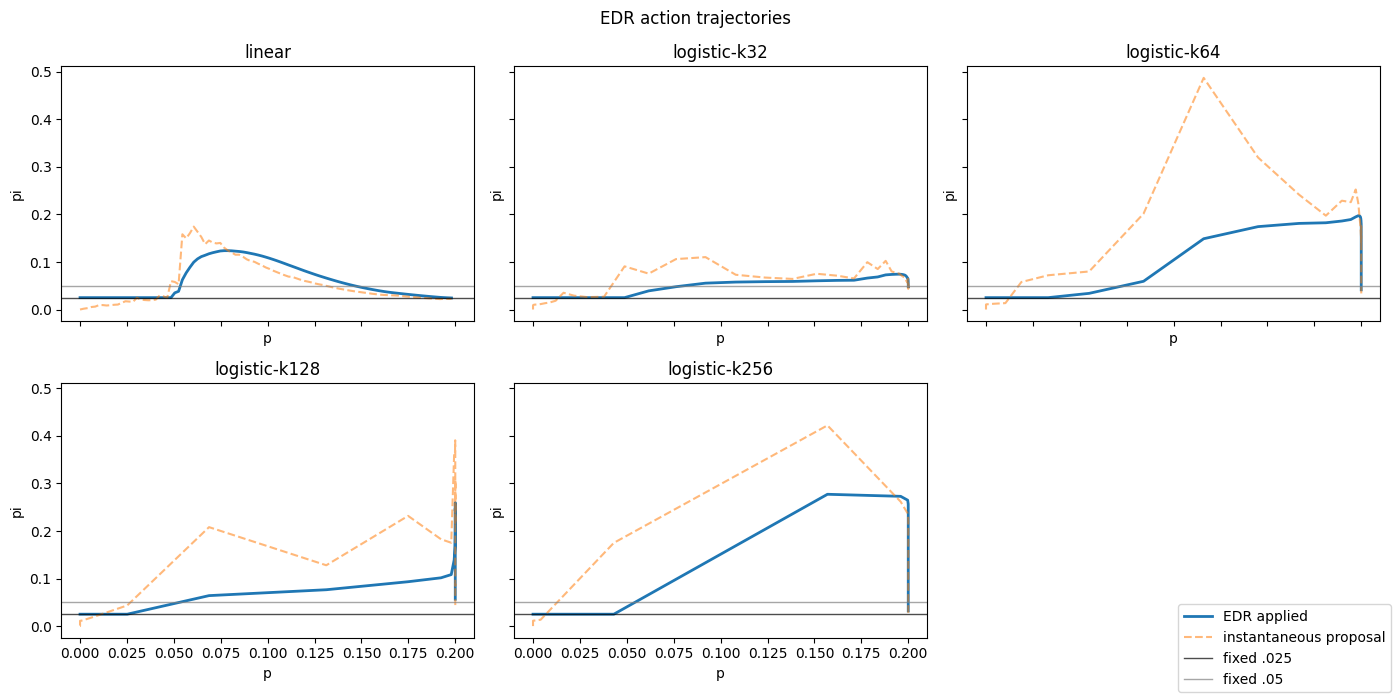

In [3]:
schedule_order = ['linear', 'logistic-k32', 'logistic-k64', 'logistic-k128', 'logistic-k256']
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for axis, schedule in zip(axes.flat, schedule_order):
    rows = SUMMARY['schedules'][schedule]['conditions']['edr-fisher-pimin001-h04']['controller']['trajectory']
    p = np.asarray([row['p'] for row in rows])
    axis.plot(p, [row['applied_pi'] for row in rows], label='EDR applied', linewidth=2)
    axis.plot(p, [row['instantaneous_plugin_pi'] for row in rows], label='instantaneous proposal', alpha=.55, linestyle='--')
    axis.axhline(.025, color='black', linewidth=1, alpha=.7, label='fixed .025')
    axis.axhline(.05, color='gray', linewidth=1, alpha=.7, label='fixed .05')
    axis.set_title(schedule)
    axis.set_xlabel('p')
    axis.set_ylabel('pi')
axes.flat[-1].axis('off')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right')
fig.suptitle('EDR action trajectories')
fig.tight_layout()

## Primary predictive comparison

Positive NLL differences are worse. EDR underperforms fixed $\pi=.025$ on every schedule, satisfying the predeclared failure gate. Its occasional improvement over the raw controller shows that coefficient smoothing removes some action noise, but not enough to make the Fisher-risk policy operationally competitive.

In [4]:
comparison_rows = []
for schedule in schedule_order:
    result = SUMMARY['schedules'][schedule]
    controller = result['conditions']['edr-fisher-pimin001-h04']['controller']
    comparison_rows.append({
        'schedule': schedule,
        'mean applied pi': controller['full_applied_pi_mean'],
        'maximum pi': controller['full_applied_pi_max'],
        'floor fraction': controller['post_cold_lower_bound_fraction'],
        'zero-risk fallbacks': controller['zero_denominator_fallback_count'],
        'NLL vs fixed .025': result['comparisons']['edr_minus_fixed_0025']['nll']['full_mean_difference'],
        'NLL vs fixed .05': result['comparisons']['edr_minus_fixed_005']['nll']['full_mean_difference'],
        'NLL vs raw adaptive': result['comparisons']['edr_minus_raw_adaptive']['nll']['full_mean_difference'],
    })
comparison_table = pd.DataFrame(comparison_rows).set_index('schedule')
comparison_table.style.format('{:.3f}')

,mean applied pi,maximum pi,floor fraction,zero-risk fallbacks,NLL vs fixed .025,NLL vs fixed .05,NLL vs raw adaptive
schedule,,,,,,,
linear,0.060,0.124,0.000,1.000,1.875,0.450,-1.189
logistic-k32,0.043,0.074,0.000,1.000,0.464,-1.114,-0.510
logistic-k64,0.072,0.197,0.000,1.000,1.144,-0.366,-0.132
logistic-k128,0.088,0.260,0.000,21.000,1.946,0.267,0.664
logistic-k256,0.067,0.277,0.000,35.000,1.808,0.375,0.464


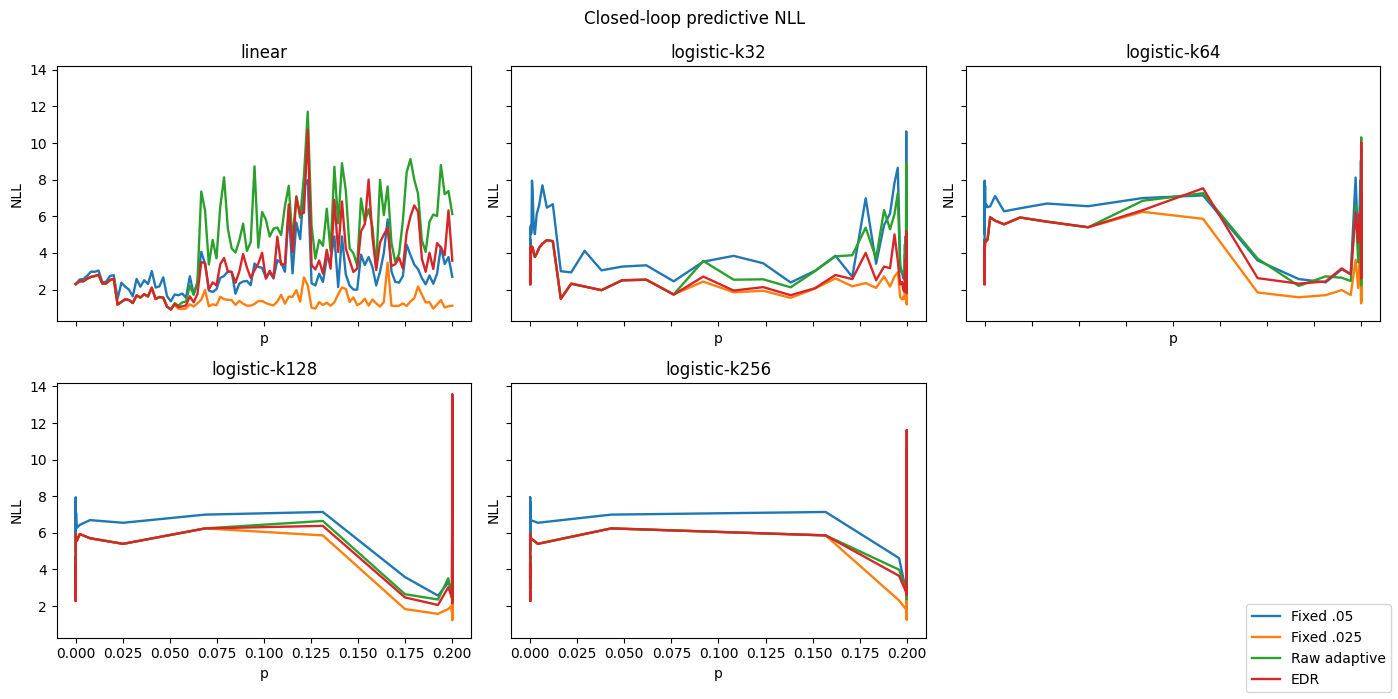

In [5]:
labels = {
    'fixed-pi005': 'Fixed .05',
    'fixed-pi0025': 'Fixed .025',
    'adaptive-fisher-pimin0025-h005': 'Raw adaptive',
    'edr-fisher-pimin001-h04': 'EDR',
}
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for axis, schedule in zip(axes.flat, schedule_order):
    for condition, label in labels.items():
        rows = SUMMARY['schedules'][schedule]['conditions'][condition]['predictive_trajectory']
        axis.plot([row['p'] for row in rows], [row['nll'] for row in rows], label=label, linewidth=1.7)
    axis.set_title(schedule)
    axis.set_xlabel('p')
    axis.set_ylabel('NLL')
axes.flat[-1].axis('off')
handles, legend_labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='lower right')
fig.suptitle('Closed-loop predictive NLL')
fig.tight_layout()

## Secondary predictive context

The table reports EDR minus each fixed policy, averaged over schedules and complete trajectories. Positive values favor EDR for accuracies and recall; negative values favor EDR for NLL and ECE. These are descriptive secondary outcomes from one outer replica.

In [6]:
metrics = ['environment_accuracy', 'nine_ovr_accuracy', 'nine_precision', 'nine_recall', 'non_nine_accuracy', 'nll', 'expected_calibration_error']
aggregate = SUMMARY['aggregate_descriptive_comparisons']
secondary = pd.DataFrame({
    'EDR - fixed .025': {metric: aggregate['edr_minus_fixed_0025'][metric]['schedule_mean_full_difference'] for metric in metrics},
    'EDR - fixed .05': {metric: aggregate['edr_minus_fixed_005'][metric]['schedule_mean_full_difference'] for metric in metrics},
    'EDR - raw adaptive': {metric: aggregate['edr_minus_raw_adaptive'][metric]['schedule_mean_full_difference'] for metric in metrics},
})
secondary.style.format('{:+.3f}')

,EDR - fixed .025,EDR - fixed .05,EDR - raw adaptive
environment_accuracy,-0.029,+0.009,+0.005
nine_ovr_accuracy,-0.008,-0.001,+0.001
nine_precision,-0.028,+0.025,+0.015
nine_recall,-0.016,+0.010,+0.011
non_nine_accuracy,-0.032,+0.004,+0.004
nll,+1.448,-0.078,-0.140
expected_calibration_error,+0.065,-0.025,-0.008


## Original Phase 6 decision

The original EDR condition is a predictive failure, not a floor-driven failure. Its cold start already used the empirically strong fixed $\pi=.025$, so this comparison answers deployment value but not whether EDR could discover a lower operating region from the historical fixed $\pi=.05$.

## Cold-start discovery amendment

This paired linear treatment changes only EDR's cold-start and exact-zero fallback action from $.025$ to $.05$. Fixed $.05$ is the primary comparator; fixed $.025$ is shown only as a hindsight benchmark.

In [7]:
DISCOVERY = ROOT / 'cache/mnist_experiment/plan4/edr/discovery/analysis/edr_discovery__7b14c111ed7b'
if not (DISCOVERY / 'COMPLETED').is_file():
    raise FileNotFoundError(f'completed EDR discovery artifact is required: {DISCOVERY}')
DISCOVERY_SUMMARY = json.loads((DISCOVERY / 'summary.json').read_text(encoding='utf-8'))
print({
    'cold-prefix parity': DISCOVERY_SUMMARY['cold_prefix_parameter_parity_with_fixed_005'],
    **DISCOVERY_SUMMARY['interpretation_gate'],
})

{'cold-prefix parity': True, 'authorizes_fresh_replica_confirmation': False, 'live_nll_difference_vs_fixed_005': 1.48775914099152, 'material_secondary_regressions': {'environment_accuracy': True, 'expected_calibration_error': True, 'nine_ovr_accuracy': False, 'nine_precision': True, 'nine_recall': True, 'non_nine_accuracy': True}, 'mechanical_discovery': True, 'predictive_discovery': False}


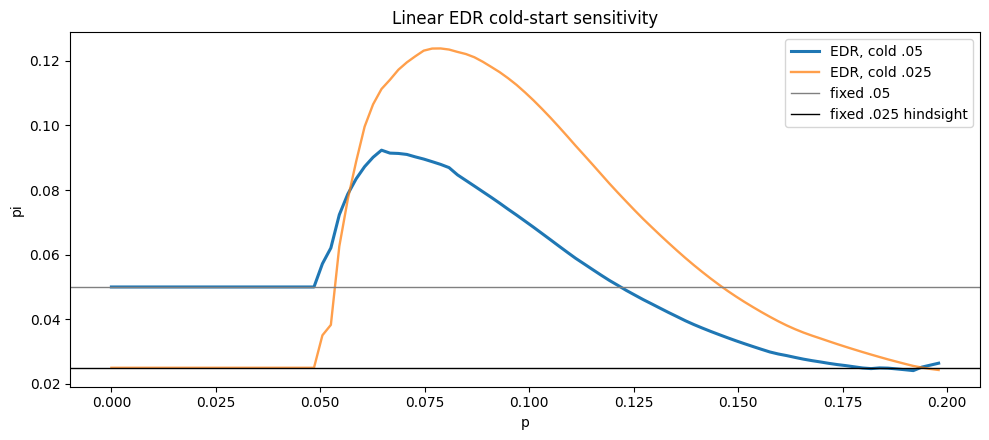

In [8]:
new_name = 'edr-fisher-pimin001-h04-cold005'
old_name = 'edr-fisher-pimin001-h04'
new_action = DISCOVERY_SUMMARY['conditions'][new_name]['controller']['trajectory']
old_action = SUMMARY['schedules']['linear']['conditions'][old_name]['controller']['trajectory']
fig, axis = plt.subplots(figsize=(10, 4.5))
axis.plot([row['p'] for row in new_action], [row['applied_pi'] for row in new_action], linewidth=2.2, label='EDR, cold .05')
axis.plot([row['p'] for row in old_action], [row['applied_pi'] for row in old_action], linewidth=1.7, alpha=.75, label='EDR, cold .025')
axis.axhline(.05, color='gray', linewidth=1, label='fixed .05')
axis.axhline(.025, color='black', linewidth=1, label='fixed .025 hindsight')
axis.set(xlabel='p', ylabel='pi', title='Linear EDR cold-start sensitivity')
axis.legend()
fig.tight_layout()

### Cold and live predictive differences

The cold prefix is exactly identical to fixed $.05$, including parameter hashes and predictive outcomes. The live column therefore isolates outcomes after EDR begins choosing its own action. Positive values favor EDR for classification metrics; negative values favor EDR for NLL and ECE.

In [9]:
discovery_comparison = DISCOVERY_SUMMARY['comparisons']['discovery_minus_fixed_005']
discovery_table = pd.DataFrame({
    'cold EDR - fixed .05': {metric: discovery_comparison['cold'][metric]['mean_difference'] for metric in metrics},
    'live EDR - fixed .05': {metric: discovery_comparison['live'][metric]['mean_difference'] for metric in metrics},
    'full EDR - fixed .05': {metric: discovery_comparison['full'][metric]['full_mean_difference'] for metric in metrics},
})
discovery_table.style.format('{:+.3f}')

,cold EDR - fixed .05,live EDR - fixed .05,full EDR - fixed .05
environment_accuracy,+0.000,-0.042,-0.032
nine_ovr_accuracy,+0.000,-0.015,-0.011
nine_precision,+0.000,-0.052,-0.048
nine_recall,+0.000,-0.040,-0.031
non_nine_accuracy,+0.000,-0.043,-0.033
nll,+0.000,+1.488,+1.127
expected_calibration_error,+0.000,+0.057,+0.043


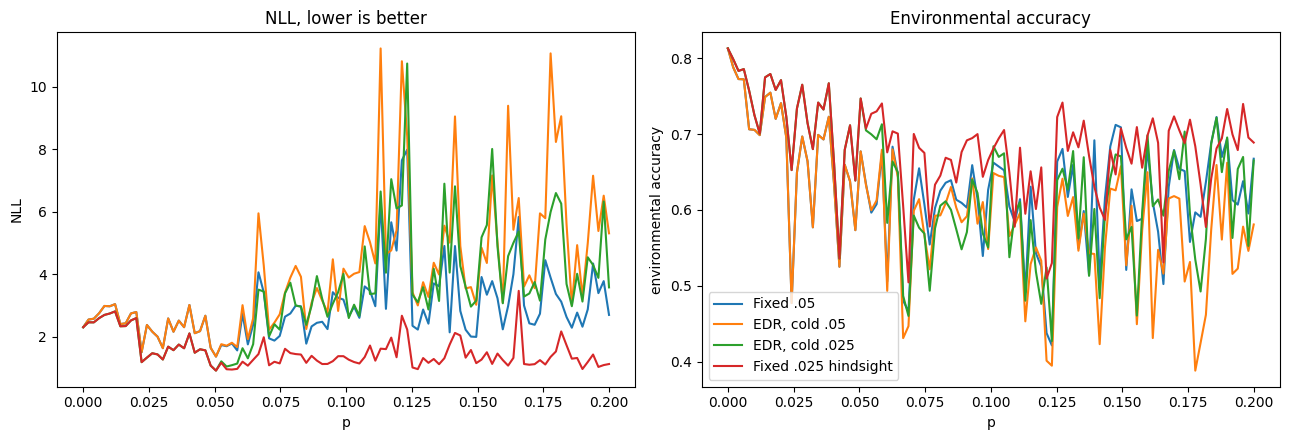

In [10]:
linear_conditions = {
    'fixed-pi005': 'Fixed .05',
    new_name: 'EDR, cold .05',
    old_name: 'EDR, cold .025',
    'fixed-pi0025': 'Fixed .025 hindsight',
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for condition, label in linear_conditions.items():
    rows = DISCOVERY_SUMMARY['conditions'][condition]['predictive_trajectory']
    axes[0].plot([row['p'] for row in rows], [row['nll'] for row in rows], label=label)
    axes[1].plot([row['p'] for row in rows], [row['environment_accuracy'] for row in rows], label=label)
axes[0].set(xlabel='p', ylabel='NLL', title='NLL, lower is better')
axes[1].set(xlabel='p', ylabel='environmental accuracy', title='Environmental accuracy')
axes[1].legend()
fig.tight_layout()

## Amended decision

EDR demonstrates **mechanical discovery**: despite starting at $.05$, its final ten unclipped actions average $.02501$. It does not demonstrate **predictive discovery**. After control becomes live, NLL is $1.49$ higher and environmental accuracy is $4.25$ percentage points lower than fixed $.05$, with material regressions in most secondary outcomes. The signal identifies a plausible operating level, but its transient actions and closed-loop path do not improve this learner.

## Sigmoid stress diagnostics

This amendment starts every EDR treatment from the historically available fixed $\pi=.05$ and varies only schedule steepness. The linear and four sigmoid schedules share one outer development replica, so contrasts across $\kappa$ describe mechanism behavior rather than independent-replica inference. Fixed $.025$ remains a hindsight reference and does not determine discovery.

In [11]:
STRESS = ROOT / 'cache/mnist_experiment/plan4/edr/stress/analysis/edr_stress__8f56773be109'
if not (STRESS / 'COMPLETED').is_file():
    raise FileNotFoundError(f'completed EDR stress artifact is required: {STRESS}')
STRESS_SUMMARY = json.loads((STRESS / 'summary.json').read_text(encoding='utf-8'))
stress_order = ['linear', 'logistic-k32', 'logistic-k64', 'logistic-k128', 'logistic-k256']
parity = pd.DataFrame([{
    'schedule': schedule,
    'last cold outcome': STRESS_SUMMARY['schedules'][schedule]['last_cold_outcome_step'],
    'parameter parity': STRESS_SUMMARY['schedules'][schedule]['cold_prefix_parameter_parity_with_fixed_005'],
    'prediction parity': STRESS_SUMMARY['schedules'][schedule]['cold_prefix_prediction_parity_with_fixed_005'],
} for schedule in stress_order]).set_index('schedule')
parity

,last cold outcome,parameter parity,prediction parity
schedule,,,
linear,25,True,True
logistic-k32,47,True,True
logistic-k64,48,True,True
logistic-k128,49,True,True
logistic-k256,50,True,True


### Single-trajectory prequential calibration

This monitor needs only the live learner. Before transition $t$, the controller predicts residual Fisher-risk energy $P_t=a_t\widehat D_{t|t-1}$ from its lagged uncertainty-scale estimate. After accepting the displacement it observes $E_t=r_t^T\widehat{\mathcal I}_{t|t-1}r_t$. The plotted statistic is $\log C_t$, where $C_t=\operatorname{EMA}_4(E_t)/\operatorname{EMA}_4(P_t)$. Zero is calibrated; positive values mean residual risk was underpredicted and negative values mean it was overpredicted. The monitor is updated during cold start, but the summaries below use only live actions. Because $\widehat D$ is learned from older residuals, this is a short-horizon staleness alarm rather than an independent goodness-of-fit test.

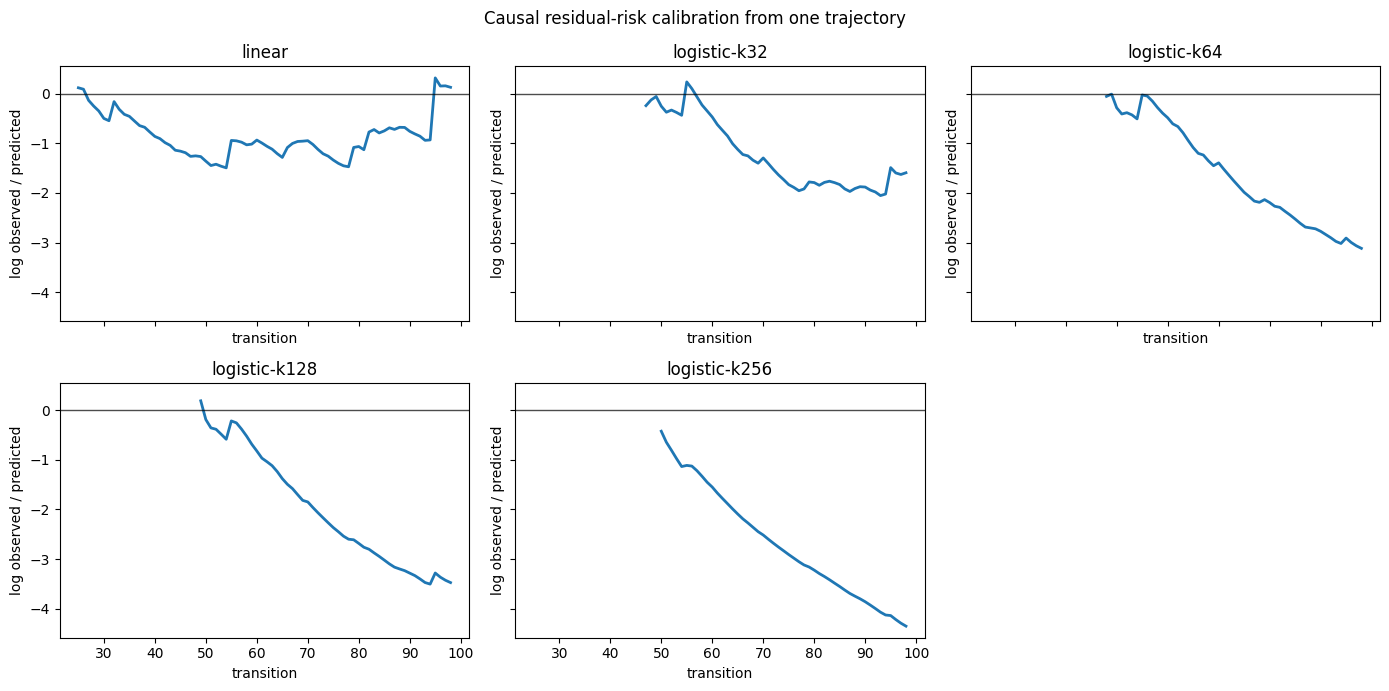

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for axis, schedule in zip(axes.flat, stress_order):
    rows = STRESS_SUMMARY['schedules'][schedule]['prequential_calibration']['trajectory']
    live = [row for row in rows if not row['cold_start_active']]
    axis.plot([row['step'] for row in live], [row['ema_log_calibration_ratio'] for row in live], linewidth=2)
    axis.axhline(0, color='black', linewidth=1, alpha=.7)
    axis.set(title=schedule, xlabel='transition', ylabel='log observed / predicted')
axes.flat[-1].axis('off')
fig.suptitle('Causal residual-risk calibration from one trajectory')
fig.tight_layout()

In [13]:
calibration_rows = []
for schedule in stress_order:
    result = STRESS_SUMMARY['schedules'][schedule]
    calibration = result['prequential_calibration']
    calibration_rows.append({
        'schedule': schedule,
        'raw ratio median': calibration['raw_ratio_median_live'],
        'EMA ratio mean': calibration['ema_ratio_mean_live'],
        'EMA ratio tail': calibration['ema_ratio_last_ten_mean'],
        'mean |log ratio|': calibration['mean_absolute_log_ema_ratio_live'],
        'tail |log ratio|': calibration['last_ten_absolute_log_ema_ratio_mean'],
        'paired NLL regression': result['comparisons']['edr_minus_fixed_005']['nll']['full_mean_difference'],
    })
pd.DataFrame(calibration_rows).set_index('schedule').style.format('{:.3f}')

,raw ratio median,EMA ratio mean,EMA ratio tail,mean |log ratio|,tail |log ratio|,paired NLL regression
schedule,,,,,,
linear,0.279,0.473,0.746,0.881,0.574,1.127
logistic-k32,0.163,0.379,0.167,1.248,1.807,0.300
logistic-k64,0.078,0.320,0.054,1.627,2.932,0.633
logistic-k128,0.041,0.253,0.034,2.012,3.376,0.700
logistic-k256,0.009,0.126,0.017,2.677,4.076,1.284


In [14]:
sensitivity_rows = []
for schedule in stress_order:
    values = STRESS_SUMMARY['schedules'][schedule]['prequential_calibration_half_life_sensitivity']
    sensitivity_rows.append({
        'schedule': schedule,
        **{f'H={half_life}': value['mean_absolute_log_ema_ratio_live'] for half_life, value in values.items()},
    })
pd.DataFrame(sensitivity_rows).set_index('schedule').style.format('{:.3f}')

,H=2,H=4,H=8
schedule,,,
linear,0.989,0.881,0.773
logistic-k32,1.437,1.248,0.896
logistic-k64,1.942,1.627,1.068
logistic-k128,2.416,2.012,1.351
logistic-k256,3.493,2.677,1.849


The monitor cleanly identifies increasing post-event scale staleness across the sigmoid family, and that ordering survives half-lives of 2, 4, and 8 updates. Retrospectively, mean absolute log miscalibration correlates with recommendation hysteresis (`0.969`) and paired NLL regression (`0.981`) across the four sigmoid paths. It does **not** diagnose the linear path's predictive failure: that residual-risk model is relatively better calibrated even though EDR still follows a worse irreversible learner trajectory than fixed $.05$. This is therefore a useful online calibration alarm, not a standalone policy-selection or predictive-performance certificate.

### Controller profiles

The solid line is realized EDR actuation, the dashed line is its unclipped recommendation, and the dotted line is the unsmoothed one-step minimizer. Shading marks the cold-start interval in which fixed $.05$ is deliberately applied while EDR accumulates risk coefficients.

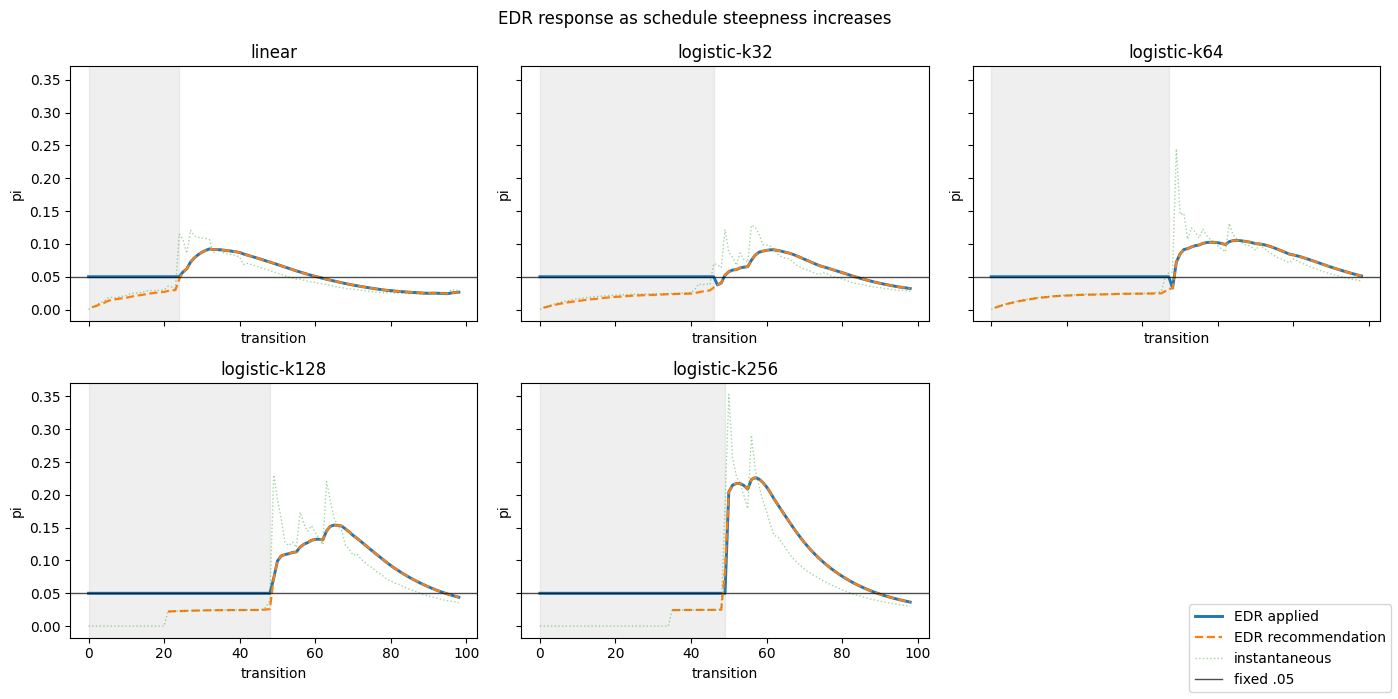

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for axis, schedule in zip(axes.flat, stress_order):
    result = STRESS_SUMMARY['schedules'][schedule]
    rows = result['controller']['trajectory']
    step = np.asarray([row['step'] for row in rows])
    axis.plot(step, [row['applied_pi'] for row in rows], linewidth=2.1, label='EDR applied')
    axis.plot(step, [np.nan if row['edr_unclipped_pi'] is None else row['edr_unclipped_pi'] for row in rows], linewidth=1.6, linestyle='--', label='EDR recommendation')
    axis.plot(step, [row['instantaneous_pi'] for row in rows], linewidth=1, alpha=.45, linestyle=':', label='instantaneous')
    axis.axhline(.05, color='black', linewidth=1, alpha=.7, label='fixed .05')
    axis.axvspan(0, result['last_cold_outcome_step'] - 1, color='gray', alpha=.12)
    axis.set(title=schedule, xlabel='transition', ylabel='pi')
axes.flat[-1].axis('off')
handles, legend_labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='lower right')
fig.suptitle('EDR response as schedule steepness increases')
fig.tight_layout()

### Continuous diagnostic summary

Positive NLL gain favors EDR; negative values favor fixed $.05$. The risk-opportunity column is the controller's nonnegative same-state quadratic improvement and is not itself a predictive result.

In [16]:
diagnostic_rows = []
for schedule in stress_order:
    result = STRESS_SUMMARY['schedules'][schedule]
    controller = result['controller']
    diagnostic_rows.append({
        'schedule': schedule,
        'tail pi': controller['settling']['last_ten_pi_mean'],
        'tail slope': controller['settling']['last_ten_pi_slope_per_step'],
        'peak pi': controller['settling']['peak_live_pi'],
        'TV / instantaneous': controller['noise_attenuation']['total_variation_ratio'],
        'risk opportunity': controller['risk']['estimated_opportunity_sum_live'],
        'NLL gain sum': result['alignment']['realized_nll_gain_sum'],
        'cumulative alignment': result['alignment']['cumulative_risk_nll_gain_correlation'],
        'floor pressure': controller['boundary']['mean_post_cold_clipping_pressure'],
    })
pd.DataFrame(diagnostic_rows).set_index('schedule').style.format('{:+.4f}')

,tail pi,tail slope,peak pi,TV / instantaneous,risk opportunity,NLL gain sum,cumulative alignment,floor pressure
schedule,,,,,,,,
linear,+0.0250,+0.0001,+0.0923,+0.5712,+0.1605,-112.7056,-0.7684,+0.0000
logistic-k32,+0.0363,-0.0010,+0.0910,+0.3603,+0.0250,-29.9903,-0.8286,+0.0000
logistic-k64,+0.0584,-0.0017,+0.1053,+0.2361,+0.0594,-63.3229,-0.8770,+0.0000
logistic-k128,+0.0523,-0.0020,+0.1539,+0.3674,+0.1413,-69.9742,-0.8820,+0.0000
logistic-k256,+0.0430,-0.0016,+0.2261,+0.4180,+0.5930,-128.3626,-0.8793,+0.0000


### Recommendation hysteresis

The curves compare the EDR recommendation at matched environmental speeds before and after each sigmoid's maximum-speed transition. Their separation is retained recommendation after the forcing has passed. Realized-action hysteresis is unavailable for $\kappa=128$ and $256$ because cold start covers too much of the entry branch; the recommendation itself remains observable.

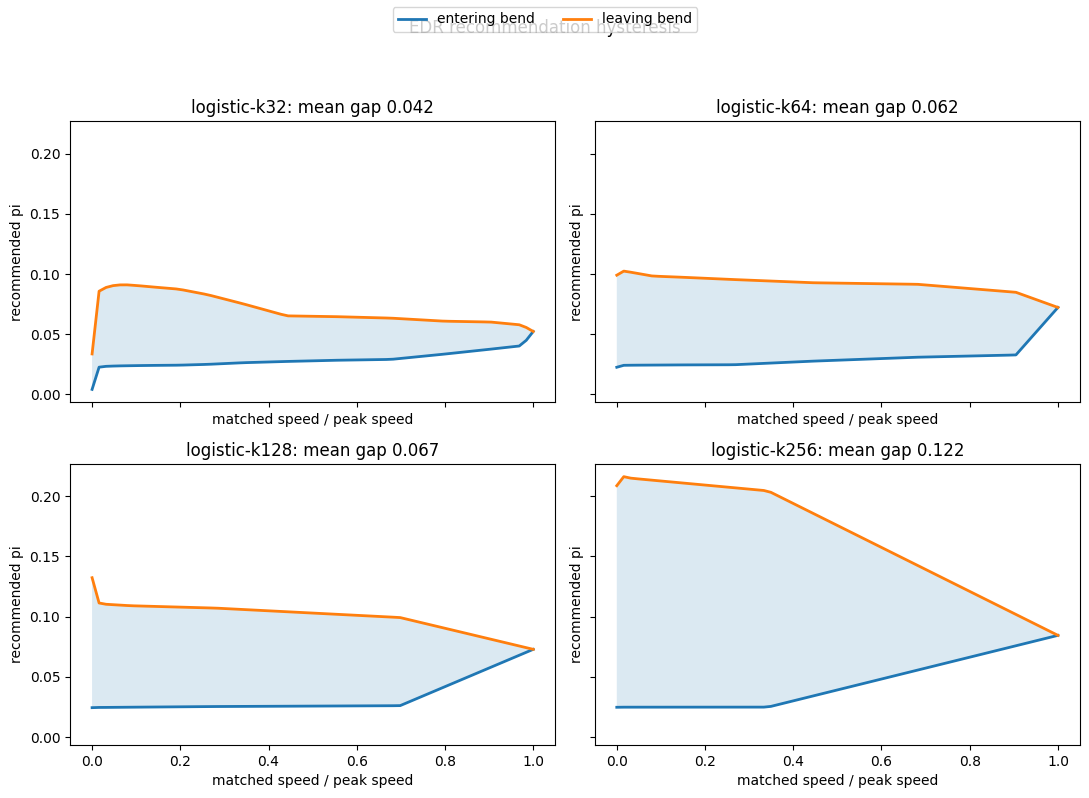

In [17]:
sigmoid_order = stress_order[1:]
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for axis, schedule in zip(axes.flat, sigmoid_order):
    loop = STRESS_SUMMARY['schedules'][schedule]['controller']['hysteresis']['unclipped_recommendation']
    rows = loop['trajectory']
    speed = np.asarray([row['speed'] for row in rows]) / loop['common_speed_max']
    axis.plot(speed, [row['entry_pi'] for row in rows], linewidth=2, label='entering bend')
    axis.plot(speed, [row['exit_pi'] for row in rows], linewidth=2, label='leaving bend')
    axis.fill_between(speed, [row['entry_pi'] for row in rows], [row['exit_pi'] for row in rows], alpha=.16)
    axis.set(title=f"{schedule}: mean gap {loop['mean_signed_branch_gap']:.3f}", xlabel='matched speed / peak speed', ylabel='recommended pi')
handles, legend_labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', ncol=2)
fig.suptitle('EDR recommendation hysteresis')
fig.tight_layout(rect=(0, 0, 1, .94))

In [18]:
response_rows = []
for schedule in stress_order:
    controller = STRESS_SUMMARY['schedules'][schedule]['controller']
    recommendation = controller['response']['unclipped_recommendation']
    loop = controller['hysteresis']['unclipped_recommendation']
    applied_loop = controller['hysteresis']['applied_live_action']
    response_rows.append({
        'schedule': schedule,
        'speed peak delay': recommendation['speed_peak_delay_steps'],
        'signal peak delay': recommendation['signal_peak_delay_steps'],
        'best signal lag': recommendation['signal_energy']['best_lag'],
        'signal association': recommendation['signal_energy']['best_correlation'],
        'recommendation hysteresis': loop.get('mean_signed_branch_gap'),
        'applied hysteresis available': applied_loop['available'],
    })
pd.DataFrame(response_rows).set_index('schedule').style.format(precision=3)

,speed peak delay,signal peak delay,best signal lag,signal association,recommendation hysteresis,applied hysteresis available
schedule,,,,,,
linear,nan,5,7,0.755,nan,False
logistic-k32,12.000,12,9,0.811,0.042,True
logistic-k64,16.000,16,7,0.481,0.062,True
logistic-k128,16.000,16,8,0.541,0.067,False
logistic-k256,8.000,7,1,0.574,0.122,False


### Claimed local gain versus realized prediction

Each panel contrasts cumulative same-state Fisher-risk opportunity with cumulative post-action NLL gain against fixed $.05$. The axes intentionally retain their different units. Agreement is descriptive because actions alter all later learner and Fisher states.

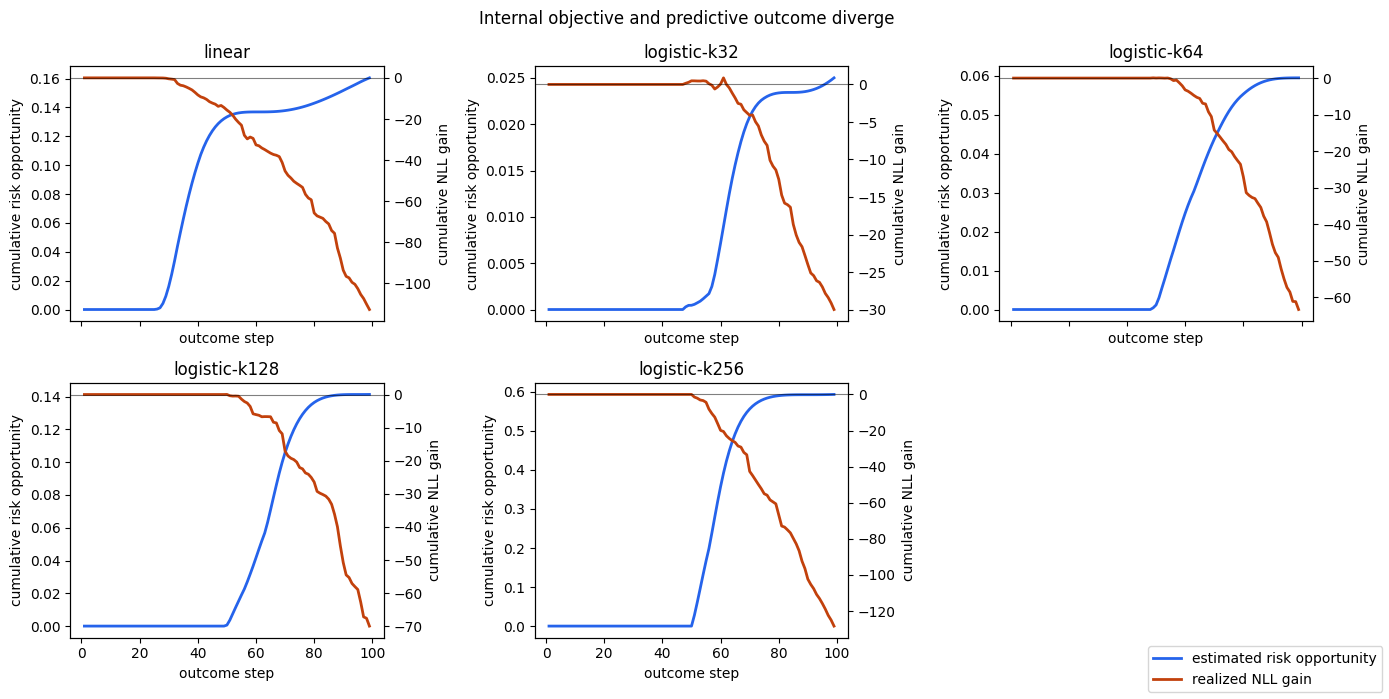

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for axis, schedule in zip(axes.flat, stress_order):
    rows = STRESS_SUMMARY['schedules'][schedule]['alignment']['trajectory']
    step = [row['step'] for row in rows]
    risk_line = axis.plot(step, [row['cumulative_estimated_risk_opportunity'] for row in rows], color='#2563eb', linewidth=2, label='estimated risk opportunity')
    twin = axis.twinx()
    nll_line = twin.plot(step, [row['cumulative_realized_nll_gain'] for row in rows], color='#c2410c', linewidth=2, label='realized NLL gain')
    twin.axhline(0, color='black', linewidth=.8, alpha=.5)
    axis.set(title=schedule, xlabel='outcome step', ylabel='cumulative risk opportunity')
    twin.set_ylabel('cumulative NLL gain')
axes.flat[-1].axis('off')
handles = risk_line + nll_line
fig.legend(handles, [line.get_label() for line in handles], loc='lower right')
fig.suptitle('Internal objective and predictive outcome diverge')
fig.tight_layout()

### Predictive context against fixed $.05$

Entries are EDR minus fixed $.05$. Positive values favor EDR for accuracy, precision, and recall; negative values favor EDR for NLL and ECE.

In [20]:
stress_metrics = ['nll', 'environment_accuracy', 'nine_ovr_accuracy', 'nine_precision', 'nine_recall', 'non_nine_accuracy', 'expected_calibration_error']
stress_predictive = pd.DataFrame({
    schedule: {metric: STRESS_SUMMARY['schedules'][schedule]['comparisons']['edr_minus_fixed_005'][metric]['full_mean_difference'] for metric in stress_metrics}
    for schedule in stress_order
}).T
stress_predictive.style.format('{:+.3f}')

,nll,environment_accuracy,nine_ovr_accuracy,nine_precision,nine_recall,non_nine_accuracy,expected_calibration_error
linear,+1.127,-0.032,-0.011,-0.048,-0.031,-0.033,+0.043
logistic-k32,+0.300,-0.007,-0.000,-0.012,+0.015,-0.013,+0.011
logistic-k64,+0.633,-0.010,-0.004,-0.023,+0.010,-0.016,+0.017
logistic-k128,+0.700,-0.005,-0.004,-0.026,+0.006,-0.008,+0.012
logistic-k256,+1.284,-0.021,-0.008,-0.061,+0.009,-0.028,+0.032


### Stress-study reading

EDR is not floor-driven and reduces instantaneous proposal variation on every schedule. Its recommendation also detects each sigmoid bend, but increasingly sharp schedules produce a delayed, positively hysteretic response: the recommendation remains elevated after environmental speed falls. The single-trajectory prequential ratio detects that growing residual-risk miscalibration without a control learner. Only the linear path settles cleanly near $.025$, and its relatively good residual calibration does not prevent predictive regression. Most importantly, estimated local Fisher-risk opportunity accumulates positively while realized NLL gain is negative on every schedule. The estimator therefore contains structured movement information, but this MNIST actuation rule converts that information into a path that is misaligned with predictive performance. EDR remains useful for theory development and online calibration monitoring, while a healthier policy needs explicit control of transient actuation and a predictive safeguard rather than a different lower bound.